In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
df = pd.read_csv("./data/processed_hospitality_data.csv",index_col=0)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                 

In [5]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [6]:
df.shape

(119390, 32)

### Checking data quality and neccessities

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isna().sum()

is_canceled                       0
lead_time                         0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          4
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
hotel                       

#### Categorical and Numerical data splitting

In [7]:
cat_col = df.select_dtypes(include="object")
cat_col.columns

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='object')

In [8]:
num_col = df.select_dtypes(include=["float64", "int64"])
num_col.columns

Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')

### Checking the distribution of the target which is 'is_canceled'

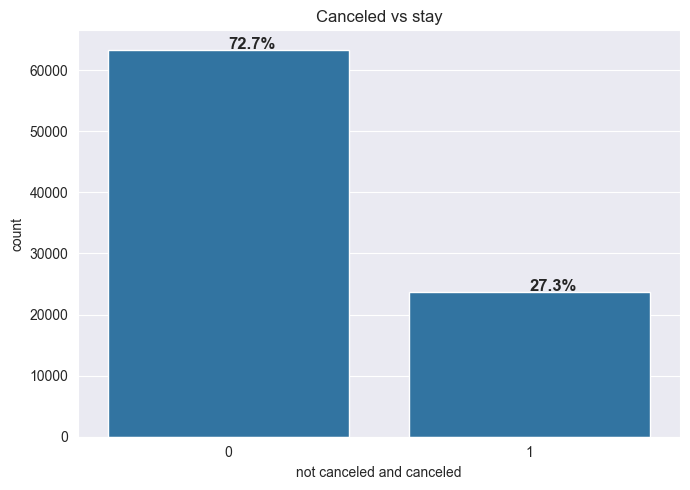

In [10]:
plt.figure(figsize=(7,5))
ax = sns.countplot(x="is_canceled", data=df)
total = len(df["is_canceled"])

# the label 
for num in ax.patches: 
    cal_perc = 100 * num.get_height() / total
    perc = f"{cal_perc:.1f}%"
    cent = num.get_x() + num.get_width() / 2 
    off_bar = num.get_height() + (total * 0.01)
    ax.annotate(perc, (cent, off_bar), size=12, fontweight="bold", va="center")

plt.title("Canceled vs stay")
plt.xlabel("not canceled and canceled")
plt.tight_layout()
plt.show()

Acoording to this chat, this result might lead the future modelling prediction to be bias in its prediction, so, this would allow me not to rely on the recall alone but also introduce the use of other metrics like precision, recall and f1_score

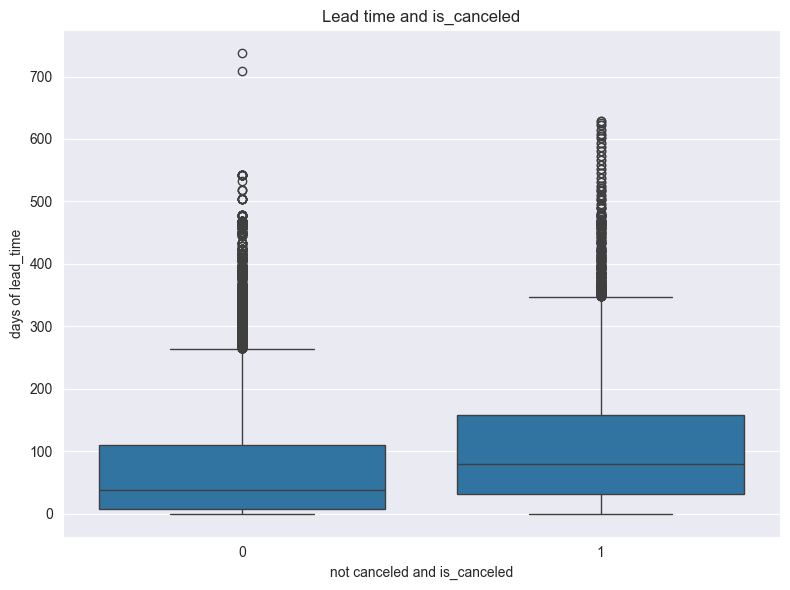

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="is_canceled", y="lead_time", data=df)
plt.title("Lead time and is_canceled")
plt.xlabel("not canceled and is_canceled")
plt.ylabel("days of lead_time")
plt.tight_layout()
plt.show()


Feature Impact on target: arrival_date_month

   arrival_date_month      mean  count
1              August  0.320545  11234
5                July  0.316760  10036
0               April  0.302145   7877
6                June  0.301175   7743
8                 May  0.288996   8315
2            December  0.266328   5114
7               March  0.242028   7495
11          September  0.241737   6656
10            October  0.234264   6911
3            February  0.230314   6083
4             January  0.219111   4678
9            November  0.208317   4978


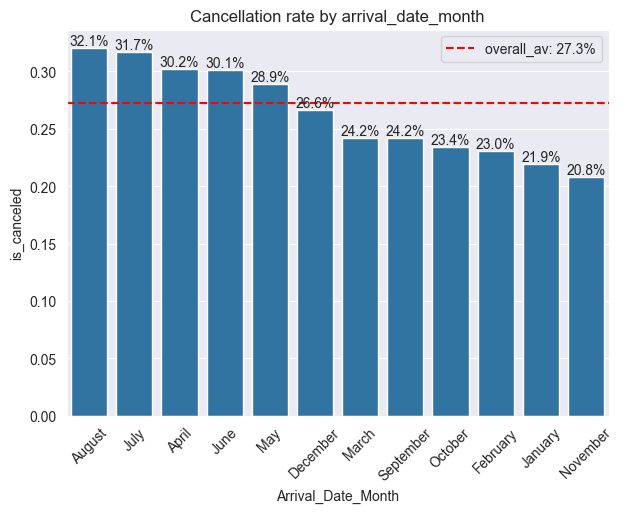


Feature Impact on target: meal

  meal      mean  count
3   SC  0.352034   9465
2   HB  0.266718   9047
0   BB  0.263387  67771


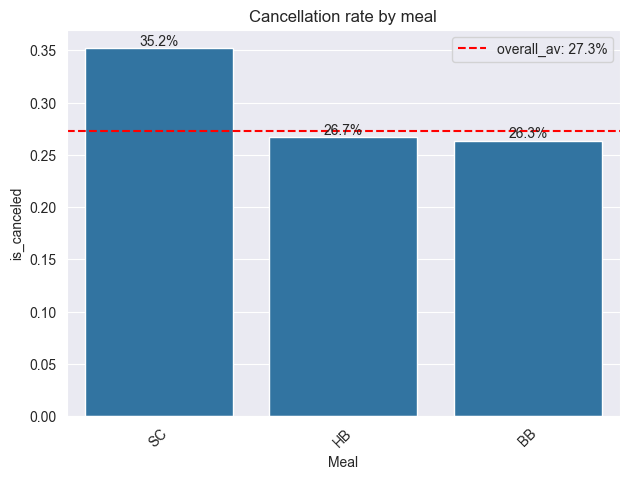


Feature Impact on target: country

    country      mean  count
25      BRA  0.363317   1990
135     PRT  0.352797  27282
81      ITA  0.348068   3054
51      ESP  0.255801   7240
29      CHE  0.244586   1570
169     USA  0.243185   1871
76      IRL  0.219155   3007
34       CN  0.204400   1091
15      BEL  0.197115   2080
56      FRA  0.195470   8830
43      DEU  0.194796   5380
59      GBR  0.188802  10413
123     NLD  0.182723   1910
12      AUT  0.175345    941


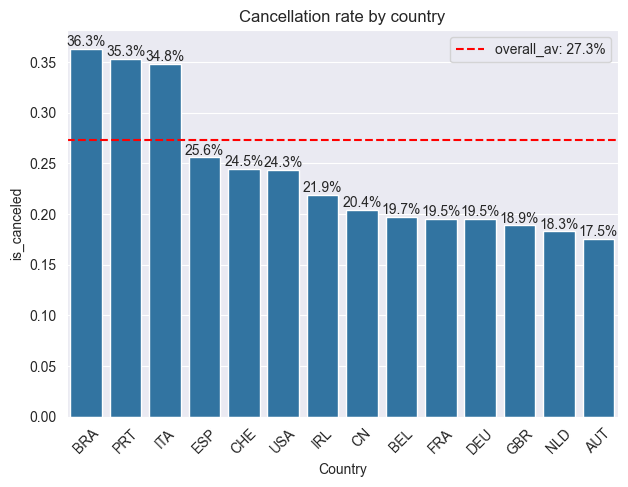


Feature Impact on target: market_segment

  market_segment      mean  count
6      Online TA  0.352027  51496
4         Groups  0.258482   4863
3         Direct  0.146528  11793
5  Offline TA/TO  0.145573  13835
2      Corporate  0.118991   4202


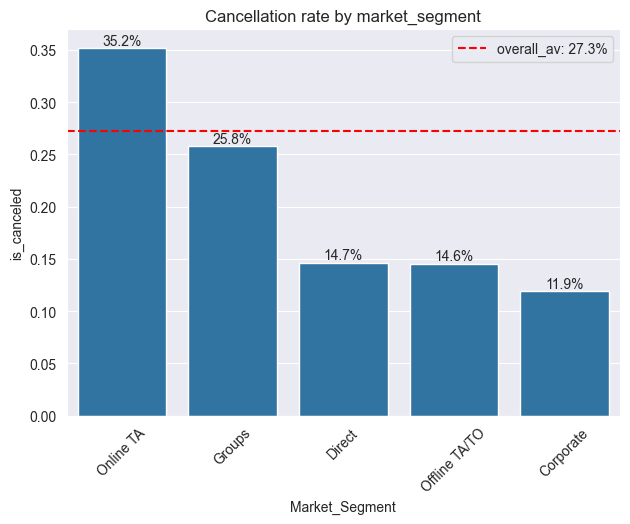


Feature Impact on target: distribution_channel

  distribution_channel      mean  count
3                TA/TO  0.307411  68898
1               Direct  0.147120  12969
0            Corporate  0.125469   5069


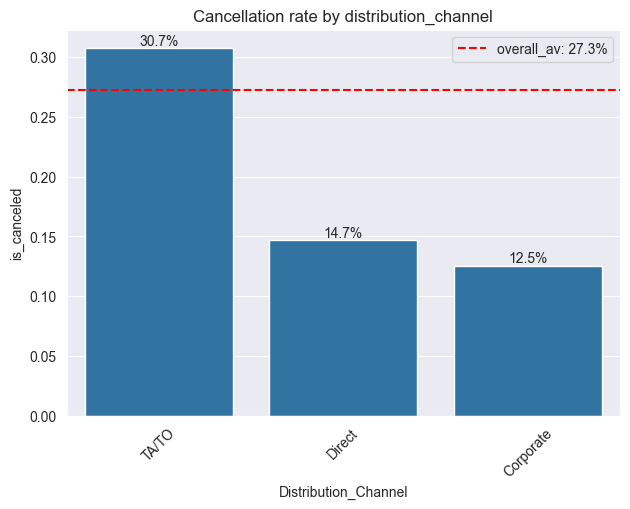


Feature Impact on target: reserved_room_type

  reserved_room_type      mean  count
6                  G  0.358224   2049
2                  C  0.322757    914
1                  B  0.318318    999
5                  F  0.300957   2821
3                  D  0.299585  17364
4                  E  0.271282   6038
0                  A  0.256982  56327


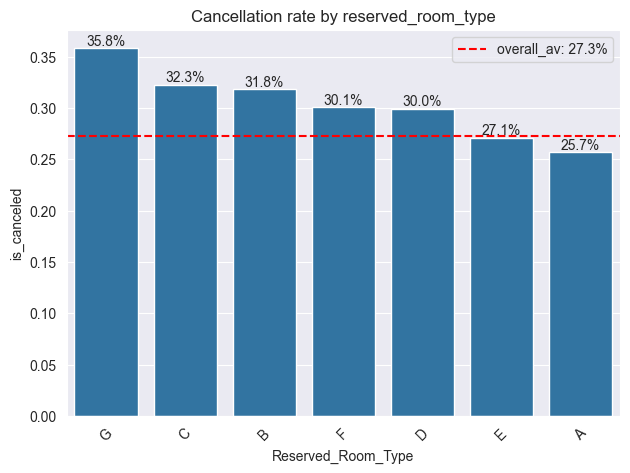


Feature Impact on target: assigned_room_type

  assigned_room_type      mean  count
0                  A  0.303185  46094
6                  G  0.300601   2495
5                  F  0.246069   3625
3                  D  0.240902  22395
4                  E  0.234827   7184
1                  B  0.218372   1818
2                  C  0.181692   2163


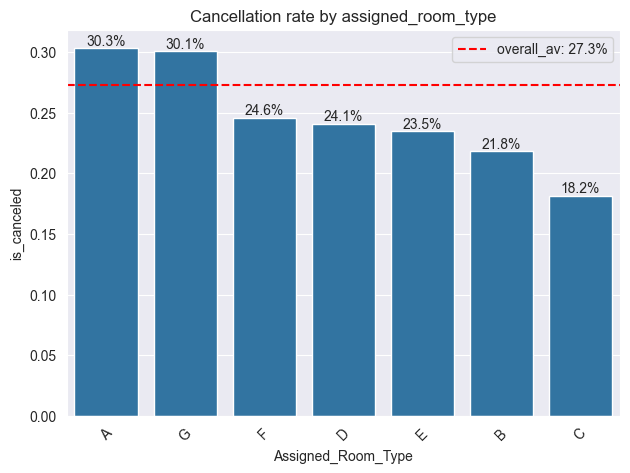


Feature Impact on target: deposit_type

  deposit_type      mean  count
1   Non Refund  0.945919   1017
0   No Deposit  0.264826  85996


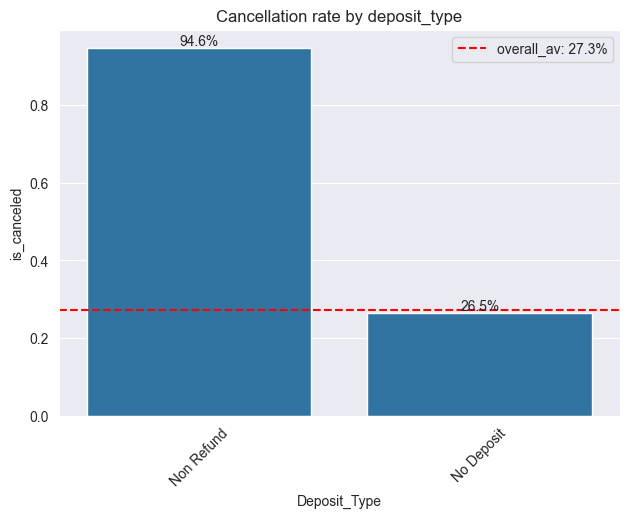


Feature Impact on target: customer_type

     customer_type      mean  count
2        Transient  0.299801  71841
0         Contract  0.162843   3138
3  Transient-Party  0.143054  11597


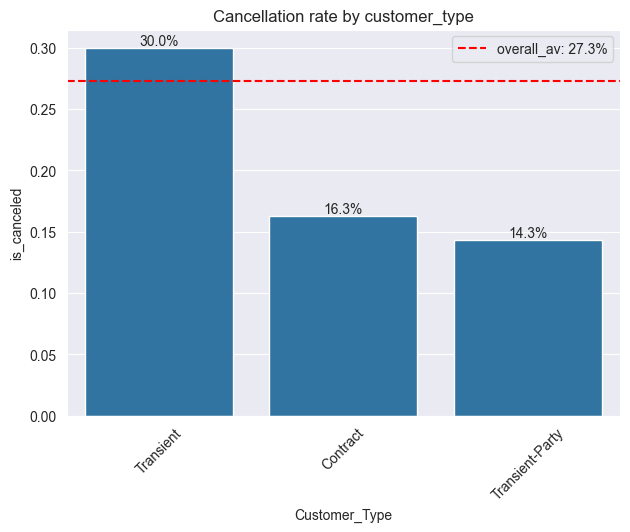


Feature Impact on target: hotel

    hotel      mean  count
0    City  0.298092  53242
1  Resort  0.232924  33878


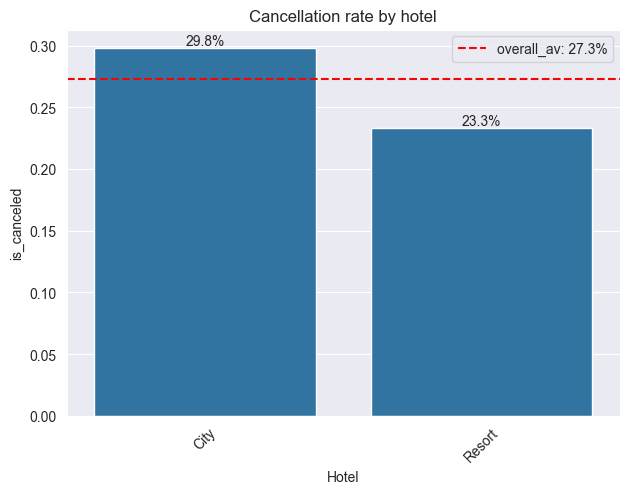

In [12]:
threshold = len(df) * 0.01
for col in cat_col:
    if col != "is_canceled": 
        value = df.groupby(col)["is_canceled"].agg(["mean", "count"]).reset_index()
        accepted_values = value[value["count"] > threshold]
        accepted_values = accepted_values.sort_values(by="mean", ascending=False)
        print (f"\nFeature Impact on target: {col}\n")
        print (accepted_values)

    ax = sns.barplot(x=col, y="mean", data=accepted_values)

    for container in ax.containers:
        total = (f"{h.get_height()*100:.1f}%" for h in container)
        ax.bar_label(container, labels=total)
     
    plt.title(f"Cancellation rate by {col}")
    plt.xlabel(f"{col.title()}")
    plt.ylabel("is_canceled")
    plt.tight_layout()
    plt.xticks(rotation=45)
    overall_mean = df["is_canceled"].mean()
    plt.axhline(overall_mean, ls="--", color="red", label=f"overall_av: {overall_mean*100:.1f}%")
    plt.legend()
    plt.show()

According to this plots, this shows a great feature that could help the model's prediction without being bias in its final result due to columns with low data but influence the cancellation rate. According to this plot, city hotel tend to influence the cancellation rate because of nature of travellers who cancels base on over booking, climate change and some other factors

Numeriacal columns

==== Numerical corr features ====

required_car_parking_spaces       0.183530
lead_time                         0.182744
adr                               0.129369
total_of_special_requests         0.118570
booking_changes                   0.092687
is_repeated_guest                 0.089145
stays_in_week_nights              0.083427
adults                            0.082316
company                           0.075160
children                          0.068491
stays_in_weekend_nights           0.060572
previous_bookings_not_canceled    0.051852
previous_cancellations            0.050905
babies                            0.020513
arrival_date_day_of_month         0.005118
days_in_waiting_list              0.001610
arrival_date_week_number          0.001140
Name: is_canceled, dtype: float64


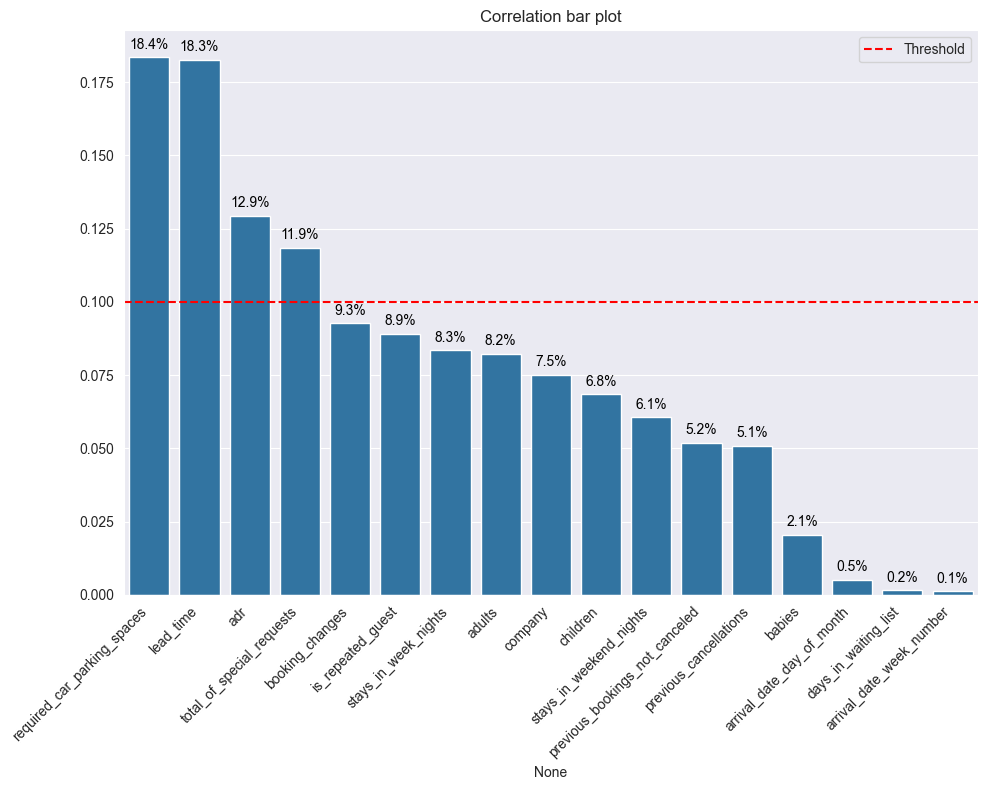

In [13]:
target_corr = df.select_dtypes(include=['number']).corr()['is_canceled'].abs()
num_corr = target_corr[target_corr.index != 'is_canceled'].sort_values(ascending=False)


print("==== Numerical corr features ====\n")
print(num_corr)

plt.figure(figsize=(10, 8))
ax = sns.barplot(x=num_corr.index, y=num_corr.values)

plt.title("Correlation bar plot")
plt.xticks(rotation=45, ha="right")

plt.axhline(y=0.1, color="red", linestyle="--", label="Threshold")
plt.legend()

for p in ax.patches: 
    height = p.get_height()
    ax.annotate(f"{height*100:.1f}%",
                (p.get_x() + p.get_width() / 2, height),
                ha="center", va="center", xytext=(0, 9),
                fontsize=10, color="black", 
                textcoords="offset points")

plt.tight_layout()
plt.show()

According to this correlation report, this showed the usable features and chosing the top 5 which appeared to not only have much of the data, but also give a reasonable percentage in the correlation report.

According to this visual plot, those features above the treshold significant line (Noise filtering line) is consider the best features to be used since they have significsnce relationship with the target. Dropping the feature lesser than 5% would reduce the noise of the ML modelliing since they indicated weak relationship with the target and if left would introduce noise causing biasness in the prediction of the model

In [14]:
target_corr = target_corr[target_corr > 0.05].index
target_corr

Index(['is_canceled', 'lead_time', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'company', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='str')

<function matplotlib.pyplot.show(close=None, block=None)>

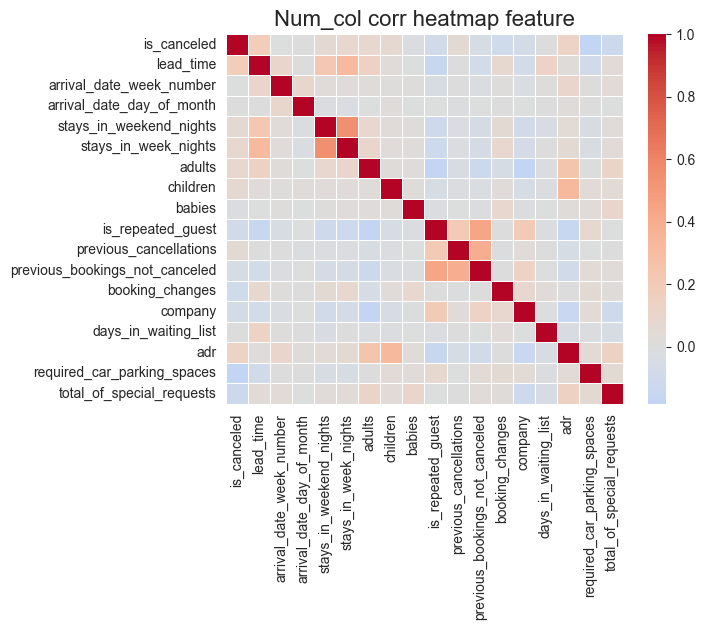

In [15]:
corr_matrix = num_col.corr()

sns.heatmap(
    corr_matrix,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5, 
    center = 0
)

plt.title("Num_col corr heatmap feature", fontsize=16)
plt.show

IndexError: index 6 is out of bounds for axis 0 with size 6

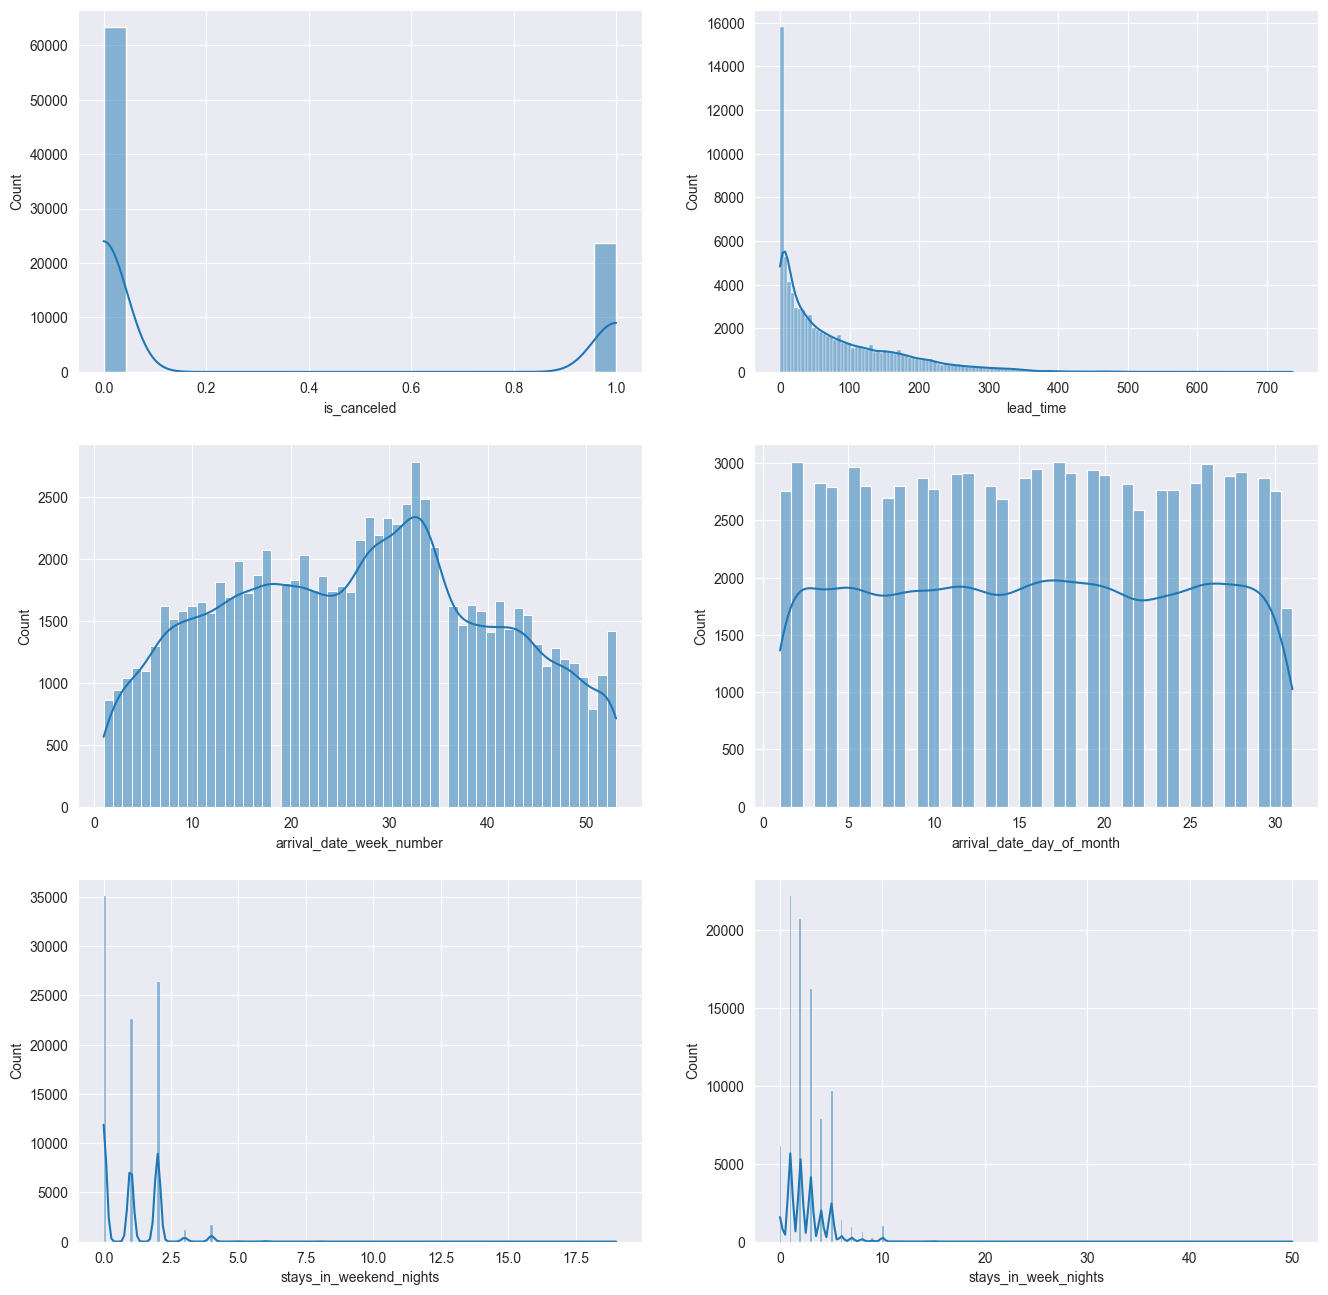

In [16]:
_, ax = plt.subplots(3, 2, figsize = (16, 16))
ax = ax.ravel() # 2D to 1D array

for ax_idx, col in enumerate(num_col):
    sns.histplot(df[col], ax=ax[ax_idx], kde=True)
ax[ax_idx].set_title(f"Distribution of {col.title()}")
ax[ax_idx].set_ylabel(f"{col.title()}")
plt.tight_layout()
plt.show()

From the plots above, lead time seams left skewed with a bit outlier at the 0 - 20 point.  

In [29]:
df.columns

Index(['is_canceled', 'lead_time', 'arrival_date_month',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'meal', 'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'company',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests', 'hotel'],
      dtype='object')

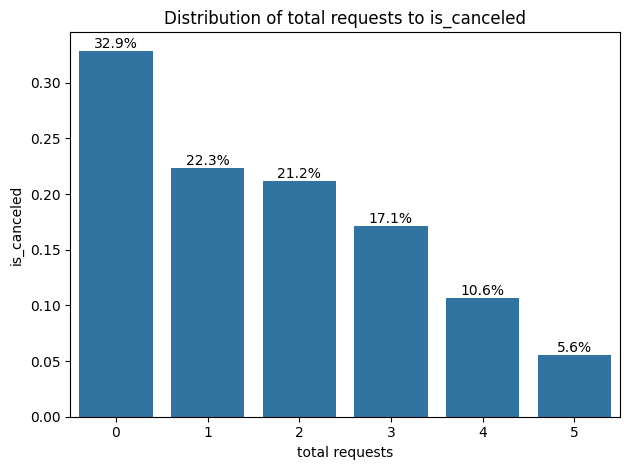

In [30]:
ax = sns.barplot(x="total_of_special_requests", y="is_canceled", data=df, errorbar=None)

for container in ax.containers:
    total = (f"{h.get_height()* 100:.1f}%" for h in container)
    ax.bar_label(container, labels=total) #, fmt="%.0f%%")
    
plt.title("Distribution of total requests to is_canceled")
plt.ylabel("is_canceled")
plt.xlabel("total requests")
plt.tight_layout()
plt.show()

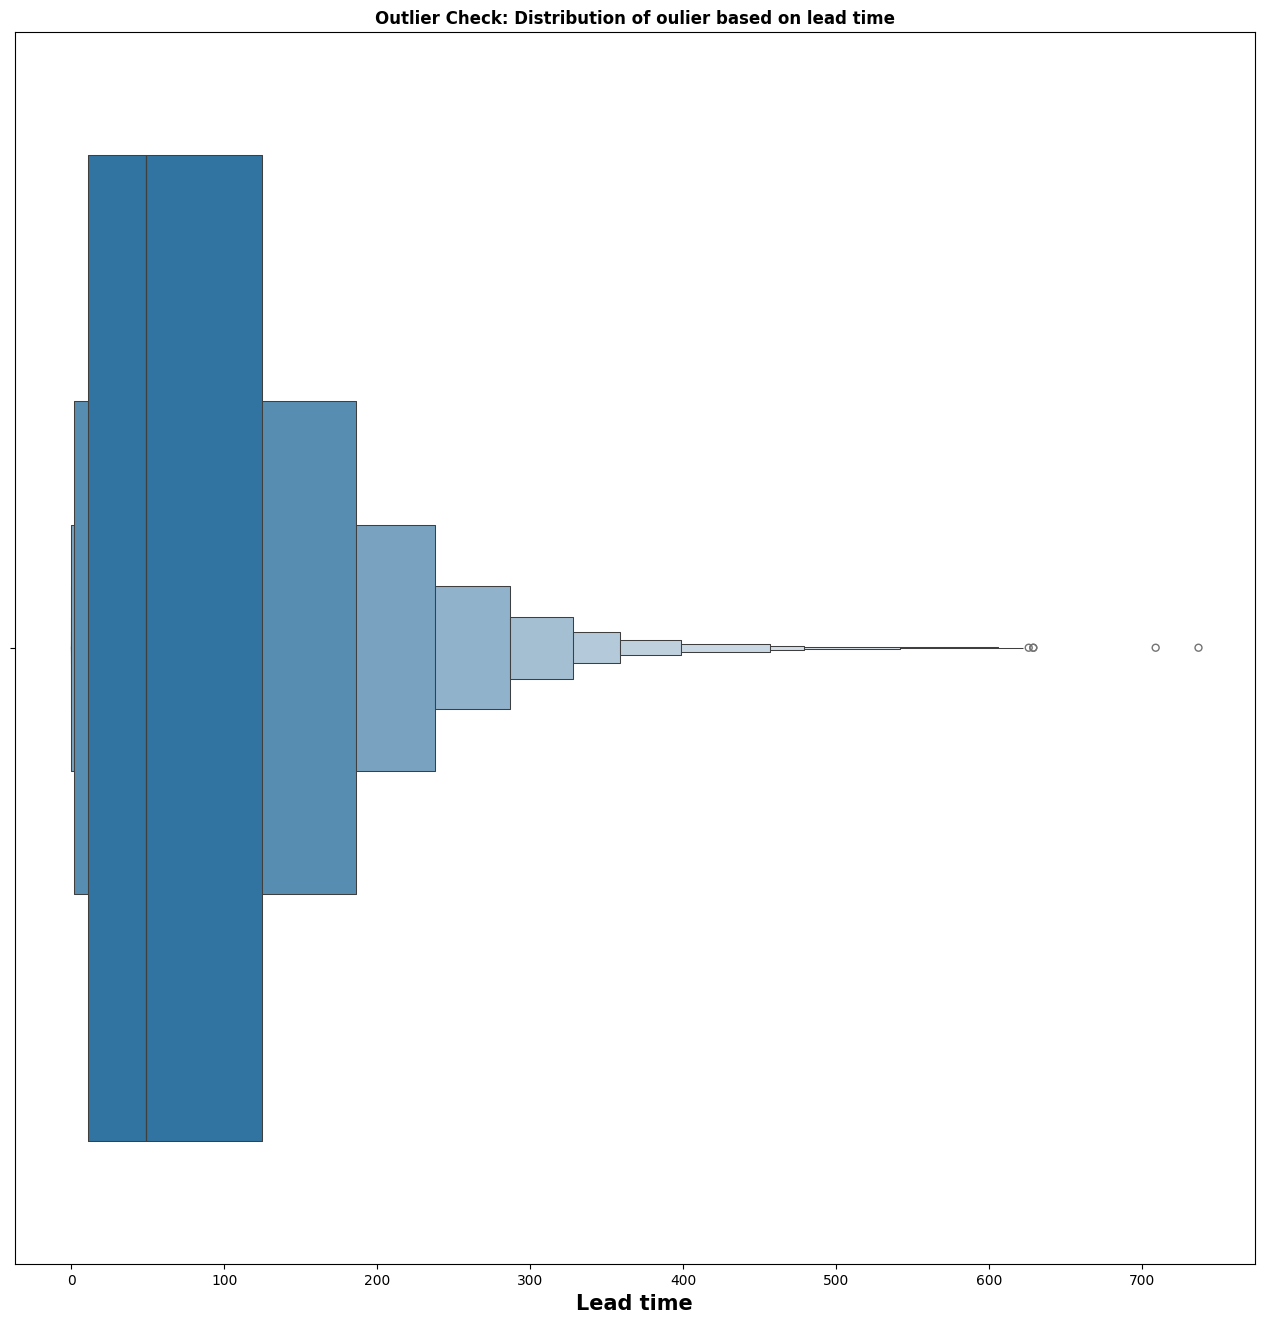

In [56]:
plt.figure(figsize=(16, 16))
sns.boxenplot(x=df["lead_time"], data=df)
plt.title("Outlier Check: Distribution of oulier based on lead time", color="black", fontweight="bold")
plt.xlabel("Lead time", fontsize=15, color="black", fontweight="bold")
plt.show()

Though this might be right, but always rare for guests to book for 2 years in advance! so, capping this into recoganising only 365 days as the highest and others higher than that would be recoganised as 365 as high risk. Why not dropping those higher than 365? Because as though it is rare, it might actually happen and that sceneroe might be a situation of a high valued guess, so, dropping those higher than 365 would include the high valued client in those dropped and this would have negative effect on the company as they would lose the client's data as regarding the client's lead time.
Log transforming it also is the same as using it but shricking the number, so i go for capping it.

In [59]:
df["lead_time"] = df["lead_time"].clip(365)

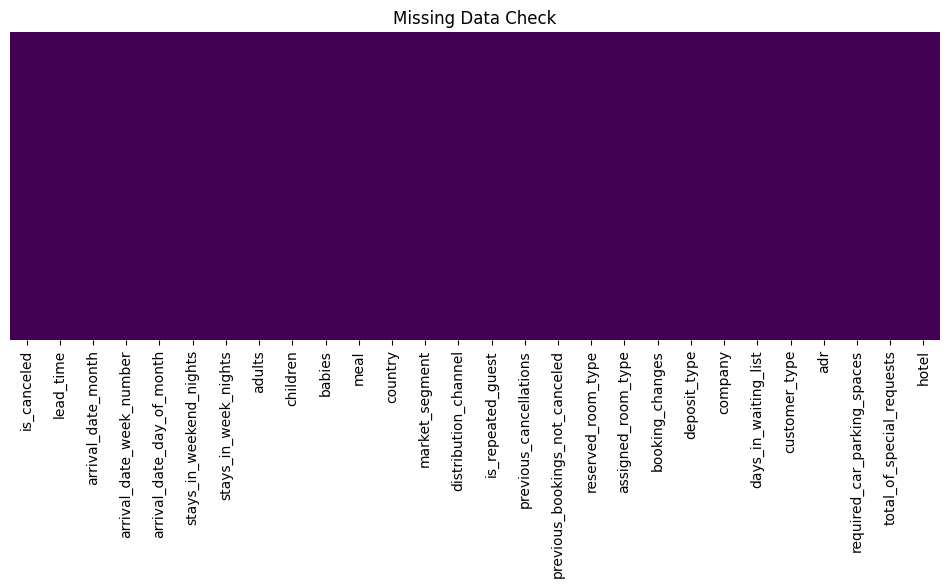

In [67]:
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Check')
plt.show()

This plot give a clear info that all columns is accurately to be used for the modelling since null has been dealt with 

In [68]:
# Making the distribution_channel column where this TA/TO to be just TA
df["distribution_channel"] = df["distribution_channel"].str.replace("/TO", "").str.strip()
df["distribution_channel"].unique()

array(['Direct', 'Corporate', 'TA', 'Undefined', 'GDS'], dtype=object)

In [69]:
df.to_csv("./data/explored_data.csv")

In [70]:
data = pd.read_csv("./data/explored_data.csv", index_col=0)
data.head()

,is_canceled,lead_time,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,assigned_room_type,booking_changes,deposit_type,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,hotel
0,0,365,July,27,1,0,0,2,0.0,0,...,C,3,No Deposit,0.0,0,Transient,0.0,0,0,Resort
1,0,737,July,27,1,0,0,2,0.0,0,...,C,4,No Deposit,0.0,0,Transient,0.0,0,0,Resort
2,0,365,July,27,1,0,1,1,0.0,0,...,C,0,No Deposit,0.0,0,Transient,75.0,0,0,Resort
3,0,365,July,27,1,0,1,1,0.0,0,...,A,0,No Deposit,0.0,0,Transient,75.0,0,0,Resort
4,0,365,July,27,1,0,2,2,0.0,0,...,A,0,No Deposit,0.0,0,Transient,98.0,0,1,Resort
